<a href="https://colab.research.google.com/github/ssj27072002/Deep-Learning-IT549/blob/main/202511048_ShubhamJoshi_Imitating_FakeSpot_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch spacy wordcloud pandas scikit-learn
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 103.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [19]:
%%writefile preprocessing.py
import pandas as pd
import torch
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

def fast_tokenize(texts):
    tokens_list = []
    for doc in nlp.pipe(texts, batch_size=1000):
        tokens_list.append([t.lemma_ for t in doc if not t.is_stop and t.is_alpha])
    return tokens_list

def encode_pad(tokens, vocab, max_len=100):
    encoded = [vocab.get(t, 0) for t in tokens[:max_len]]
    return encoded + [0] * (max_len - len(encoded))

def get_preprocessed_data(csv_path):
    df = pd.read_csv(csv_path)
    df['text_'] = df['text_'].astype(str)
    df['tokens'] = fast_tokenize(df['text_'].tolist())
    all_tokens = [t for sublist in df['tokens'] for t in sublist]
    vocab = {word: i+1 for i, (word, _) in enumerate(Counter(all_tokens).most_common(10000))}
    X = torch.tensor([encode_pad(t, vocab) for t in df['tokens']])
    return df, X, vocab

Writing preprocessing.py


In [20]:
%%writefile models.py
import torch.nn as nn

class MulticlassClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.network = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        embedded = self.embedding(x).mean(dim=1)
        return self.network(embedded)

class BinaryClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.network = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        embedded = self.embedding(x).mean(dim=1)
        return self.network(embedded)

Writing models.py


In [21]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader, Dataset

# These will now work because of the cells above
from preprocessing import get_preprocessed_data
from models import MulticlassClassifier

class ReviewDataset(Dataset):
    def __init__(self, x, y):
        self.x, self.y = x, y
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

# 1. Load data
df, X, vocab = get_preprocessed_data('fake_reviews_dataset.csv')
le_cat = LabelEncoder()
y_cat = torch.tensor(le_cat.fit_transform(df['category']), dtype=torch.long)

# 2. Split
train_idx, test_idx = train_test_split(range(len(X)), test_size=0.2, random_state=42, stratify=df['category'])
train_loader = DataLoader(ReviewDataset(X[train_idx], y_cat[train_idx]), batch_size=64, shuffle=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 3. Model & Train
model = MulticlassClassifier(len(vocab), 100, len(le_cat.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

print("Starting Training...")
for epoch in range(5):
    model.train()
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(texts), labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} complete.")

# 4. Final Report
model.eval()
y_pred = []
with torch.no_grad():
    test_inputs = X[test_idx].to(device)
    outputs = model(test_inputs)
    y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

print("\nProduct Category Classification Report:")
print(classification_report(y_cat[test_idx], y_pred, target_names=le_cat.classes_))

Starting Training...
Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.

Product Category Classification Report:
                              precision    recall  f1-score   support

                     Books_5       0.72      0.70      0.71       874
Clothing_Shoes_and_Jewelry_5       0.78      0.75      0.76       770
               Electronics_5       0.76      0.76      0.76       798
          Home_and_Kitchen_5       0.63      0.64      0.64       811
              Kindle_Store_5       0.76      0.76      0.76       946
             Movies_and_TV_5       0.87      0.86      0.87       717
              Pet_Supplies_5       0.88      0.82      0.85       851
       Sports_and_Outdoors_5       0.54      0.56      0.55       789
Tools_and_Home_Improvement_5       0.65      0.69      0.67       772
            Toys_and_Games_5       0.78      0.80      0.79       759

                    accuracy                           0.73      8087
      

In [22]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os
from preprocessing import get_preprocessed_data

df, _, _ = get_preprocessed_data('fake_reviews_dataset.csv')

if not os.path.exists('results'):
    os.makedirs('results')

for cat in df['category'].unique():
    # Filter for Fake (CG) reviews in the specific category
    subset = df[(df['category'] == cat) & (df['label'] == 'CG')]
    # Join tokens into a single string
    text = " ".join([" ".join(tokens) for tokens in subset['tokens']])

    if len(text.strip()) > 0:
        wc = WordCloud(width=800, height=400, background_color='white').generate(text)

        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Fake Review Patterns: {cat}")

        # Save unique file for each category
        file_name = f"results/wordcloud_{cat}.png"
        plt.savefig(file_name)
        plt.close()
        print(f"Generated Word Cloud for {cat}")

Generated Word Cloud for Home_and_Kitchen_5
Generated Word Cloud for Sports_and_Outdoors_5
Generated Word Cloud for Electronics_5
Generated Word Cloud for Movies_and_TV_5
Generated Word Cloud for Tools_and_Home_Improvement_5
Generated Word Cloud for Pet_Supplies_5
Generated Word Cloud for Kindle_Store_5
Generated Word Cloud for Books_5
Generated Word Cloud for Toys_and_Games_5
Generated Word Cloud for Clothing_Shoes_and_Jewelry_5


Generating and displaying images...


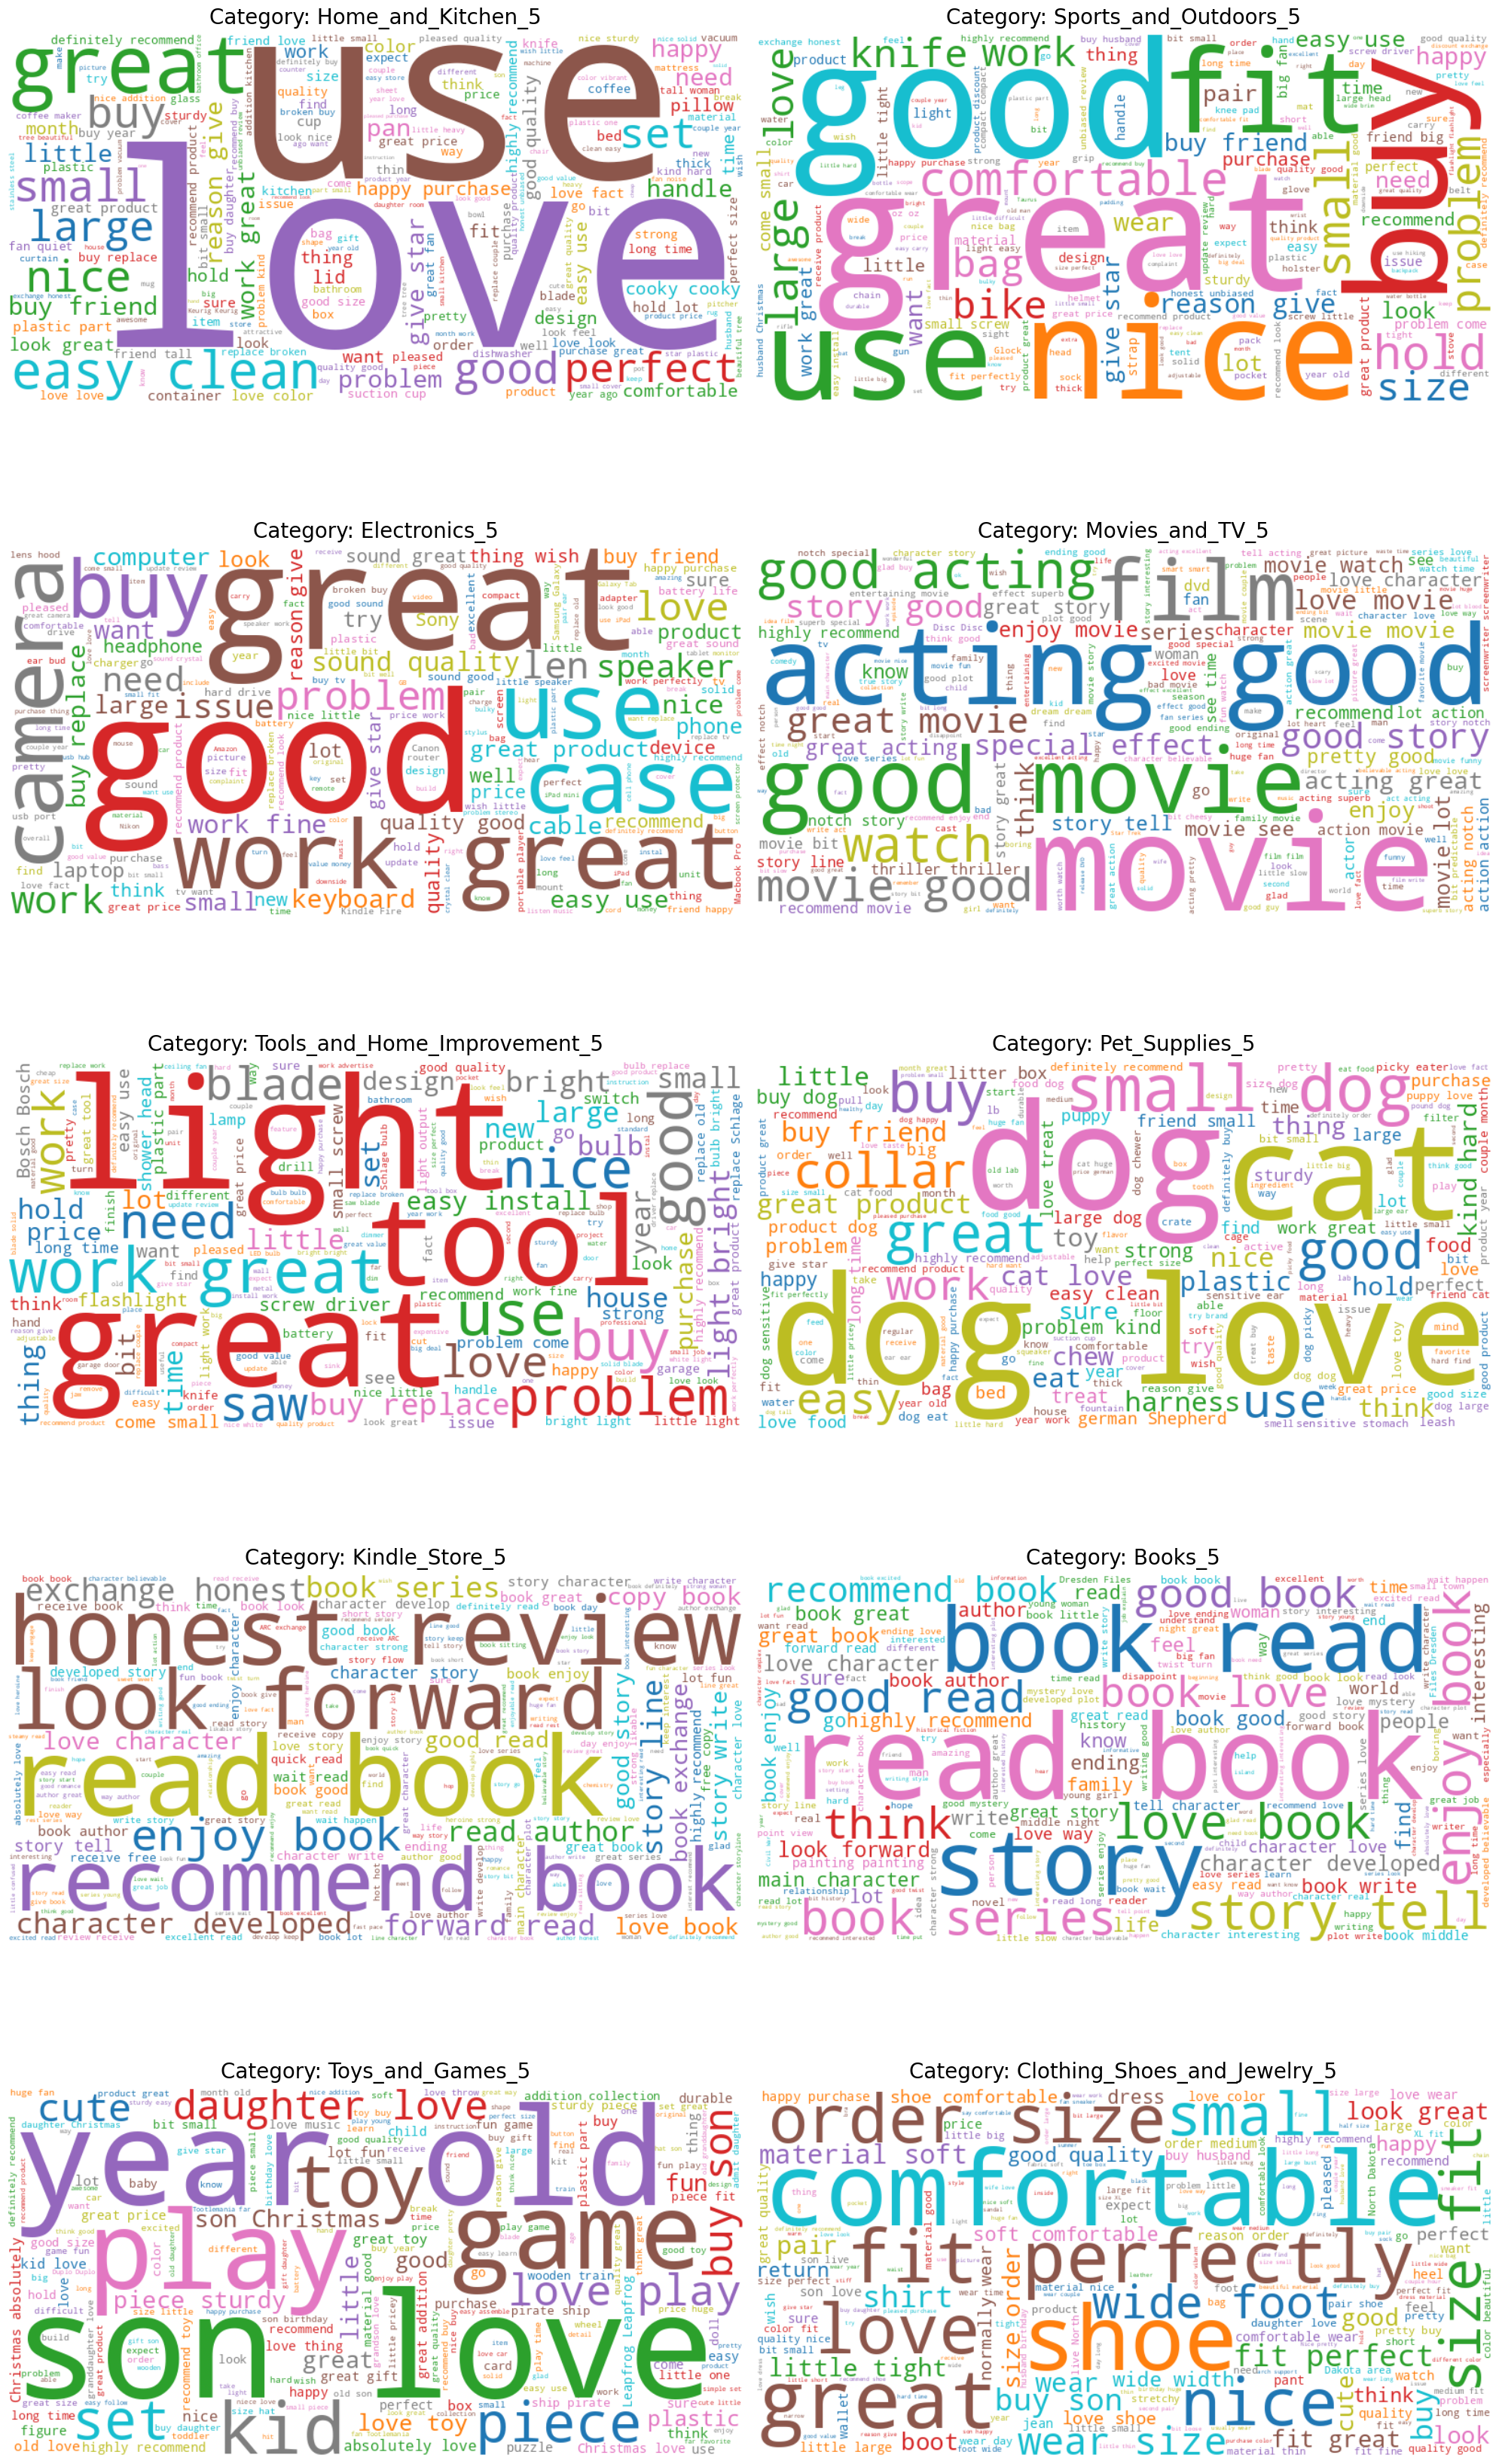

In [24]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from preprocessing import get_preprocessed_data

# 1. Load the preprocessed data
df, _, _ = get_preprocessed_data('fake_reviews_dataset.csv')

# 2. Get unique categories
categories = df['category'].unique()

# 3. Setup the grid (5 rows, 2 columns for 10 categories)
fig, axes = plt.subplots(5, 2, figsize=(20, 35))
axes = axes.flatten()

print("Generating and displaying images...")

for i, cat in enumerate(categories):
    # Filter for Fake (CG) reviews in this category
    subset = df[(df['category'] == cat) & (df['label'] == 'CG')]

    # Combine tokens into a single text string
    text = " ".join([" ".join(tokens) for tokens in subset['tokens']])

    if len(text.strip()) > 0:
        # Generate WordCloud
        wc = WordCloud(width=800, height=400, background_color='white', colormap='tab10').generate(text)

        # Plot in the specific subplot
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f"Category: {cat}", fontsize=20, pad=10)
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f"No Fake Reviews found for\n{cat}",
                     ha='center', va='center', fontsize=14)
        axes[i].axis('off')



plt.tight_layout()
plt.show()